# IC3392 7000 vs 8900 Product Comparison

Compare IC3392 products from `v3tk_v7.6.8_7000` against `v3tk_v7.6.8`.

The `_7000` run is the fiducial/reference run. Residual convention in this notebook: `v3tk_v7.6.8 - v3tk_v7.6.8_7000`.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from IPython.display import display

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 160,
    'axes.grid': False,
    'font.size': 10,
})

root = Path('/Users/Igniz/Desktop/ICRAR/further')

RUNS = {
    'fiducial_7000': {
        'label': 'v3tk_v7.6.8_7000',
        'path': root / 'v3tk_v7.6.8_7000' / 'IC3392',
        'sfh_file': 'IC3392_sfh_maps.fits',
        'kin_file': 'IC3392_kin_maps.fits',
        'gas_bin_file': 'IC3392_gas_bin_maps.fits',
    },
    'test_8900': {
        'label': 'v3tk_v7.6.8',
        'path': root / 'v3tk_v7.6.8' / 'IC3392',
        'sfh_file': 'IC3392_sfh_maps.fits',
        'kin_file': 'IC3392_kin_maps.fits',
        'gas_bin_file': 'IC3392_gas_bin_maps.fits',
    },
}

MAP_ORDER = ['fiducial_7000', 'test_8900']
REF_KEY = 'fiducial_7000'
TEST_KEY = 'test_8900'

PROPERTIES = {
    'AGE': {
        'label': 'SFH age',
        'file_key': 'sfh_file',
        'hdu': 'AGE',
        'unit': 'Gyr',
        'cmap': 'cividis',
        'scatter_log_axes': True,
    },
    'METAL': {
        'label': 'SFH metallicity',
        'file_key': 'sfh_file',
        'hdu': 'METAL',
        'unit': 'dex',
        'cmap': 'plasma',
    },
    'V': {
        'label': 'stellar velocity',
        'file_key': 'kin_file',
        'hdu': 'V',
        'unit': 'km/s',
        'cmap': 'RdBu_r',
    },
    'SIGMA': {
        'label': 'stellar velocity dispersion',
        'file_key': 'kin_file',
        'hdu': 'SIGMA',
        'unit': 'km/s',
        'cmap': 'magma',
    },
    'HA6562_FLUX': {
        'label': 'Halpha flux',
        'file_key': 'gas_bin_file',
        'hdu': 'HA6562_FLUX',
        'unit': 'flux',
        'cmap': 'inferno',
        'scatter_log_axes': True,
        'scatter_log_residual': True,
    },
    'HA6562_VEL': {
        'label': 'Halpha velocity',
        'file_key': 'gas_bin_file',
        'hdu': 'HA6562_VEL',
        'unit': 'km/s',
        'cmap': 'RdBu_r',
    },
}

for run in RUNS.values():
    for key in ('sfh_file', 'kin_file', 'gas_bin_file'):
        path = run['path'] / run[key]
        if not path.exists():
            raise FileNotFoundError(path)

print('Configured runs:')
for key, run in RUNS.items():
    print(f"  {key:14s}: {run['label']} -> {run['path']}")


Configured runs:
  fiducial_7000 : v3tk_v7.6.8_7000 -> /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8_7000/IC3392
  test_8900     : v3tk_v7.6.8 -> /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8/IC3392


## Load Products

Load the requested map HDUs from `_sfh_maps.fits`, `_kin_maps.fits`, and `_gas_bin_maps.fits`. The comparison uses the overlapping finite footprint for each property.


In [2]:
def read_image(path, hdu):
    with fits.open(path, memmap=True) as hdul:
        data = np.array(hdul[hdu].data, dtype=float)
        header = hdul[hdu].header.copy()
    return data, header


def finite_limits(values, qlo=1, qhi=99):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return 0.0, 1.0
    lo, hi = np.nanpercentile(arr, [qlo, qhi])
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        lo, hi = np.nanmin(arr), np.nanmax(arr)
    if lo == hi:
        pad = abs(lo) * 0.05 if lo else 1.0
        lo -= pad
        hi += pad
    return lo, hi


def symmetric_limits(values, q=99):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return -1.0, 1.0
    lim = np.nanpercentile(np.abs(arr), q)
    if not np.isfinite(lim) or lim == 0:
        lim = np.nanmax(np.abs(arr))
    if not np.isfinite(lim) or lim == 0:
        lim = 1.0
    return -lim, lim


def nmad(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return np.nan
    med = np.nanmedian(arr)
    return 1.4826 * np.nanmedian(np.abs(arr - med))

map_data = {run_key: {} for run_key in MAP_ORDER}
map_headers = {run_key: {} for run_key in MAP_ORDER}

for run_key in MAP_ORDER:
    run = RUNS[run_key]
    for prop_key, prop in PROPERTIES.items():
        path = run['path'] / run[prop['file_key']]
        map_data[run_key][prop_key], map_headers[run_key][prop_key] = read_image(path, prop['hdu'])
        print(f"{run['label']:18s} {prop_key:12s} shape={map_data[run_key][prop_key].shape}")


v3tk_v7.6.8_7000   AGE          shape=(438, 437)
v3tk_v7.6.8_7000   METAL        shape=(438, 437)
v3tk_v7.6.8_7000   V            shape=(438, 437)
v3tk_v7.6.8_7000   SIGMA        shape=(438, 437)
v3tk_v7.6.8_7000   HA6562_FLUX  shape=(438, 437)
v3tk_v7.6.8_7000   HA6562_VEL   shape=(438, 437)
v3tk_v7.6.8        AGE          shape=(438, 437)
v3tk_v7.6.8        METAL        shape=(438, 437)
v3tk_v7.6.8        V            shape=(438, 437)
v3tk_v7.6.8        SIGMA        shape=(438, 437)
v3tk_v7.6.8        HA6562_FLUX  shape=(438, 437)
v3tk_v7.6.8        HA6562_VEL   shape=(438, 437)


## Spatial Maps

For each property, the first panel is the `_7000` fiducial map, the second panel is the comparison `v3tk_v7.6.8` map, and the third panel is the direct residual.


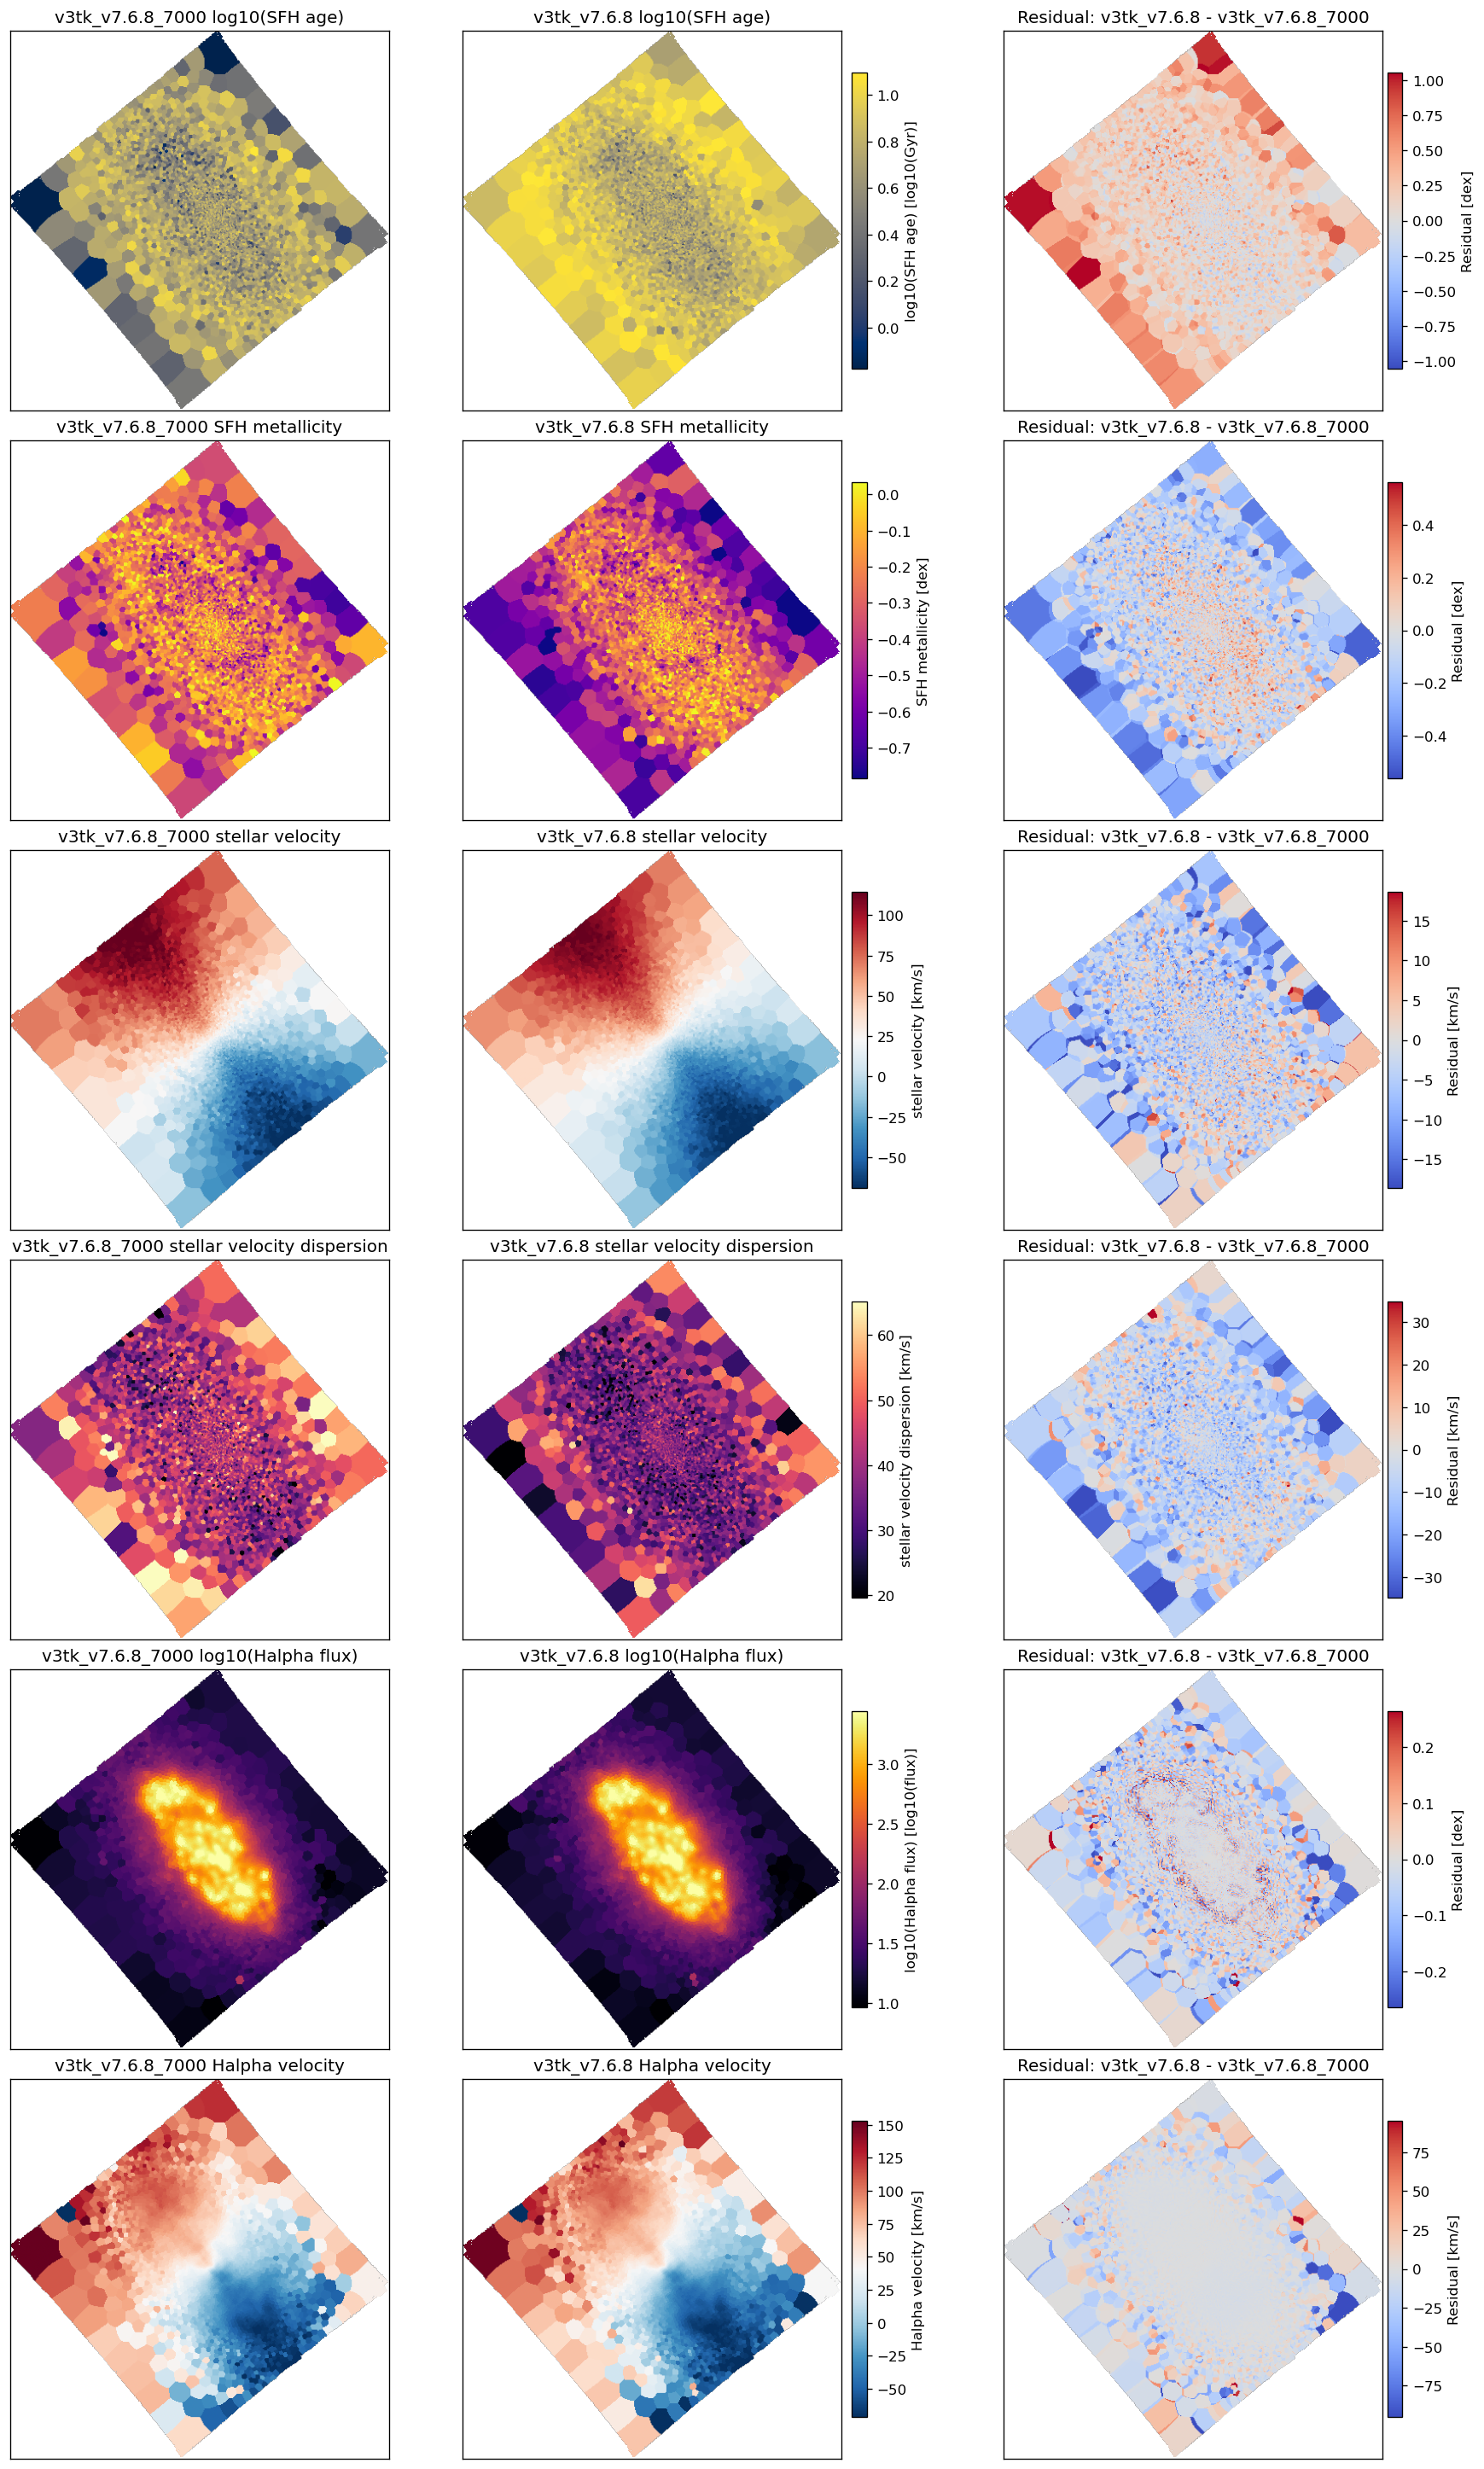

In [3]:
fig, axes = plt.subplots(len(PROPERTIES), 3, figsize=(15.0, 4.0 * len(PROPERTIES)), constrained_layout=True)
if axes.ndim == 1:
    axes = axes[None, :]

for row, (prop_key, prop) in enumerate(PROPERTIES.items()):
    ref = map_data[REF_KEY][prop_key]
    test = map_data[TEST_KEY][prop_key]
    
    use_log = prop.get('scatter_log_axes', False)
    if use_log:
        ref_plot = np.log10(np.where(ref > 0, ref, np.nan))
        test_plot = np.log10(np.where(test > 0, test, np.nan))
        label_suffix = f"log10({prop['label']})"
        unit_str = f"log10({prop['unit']})"
    else:
        ref_plot = ref
        test_plot = test
        label_suffix = prop['label']
        unit_str = prop['unit']
        
    combined = np.concatenate([ref_plot.ravel(), test_plot.ravel()])
    vmin, vmax = finite_limits(combined)

    im0 = axes[row, 0].imshow(ref_plot, origin='lower', cmap=prop['cmap'], vmin=vmin, vmax=vmax)
    axes[row, 0].set_title(f"{RUNS[REF_KEY]['label']} {label_suffix}")
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])

    im1 = axes[row, 1].imshow(test_plot, origin='lower', cmap=prop['cmap'], vmin=vmin, vmax=vmax)
    axes[row, 1].set_title(f"{RUNS[TEST_KEY]['label']} {label_suffix}")
    axes[row, 1].set_xticks([])
    axes[row, 1].set_yticks([])
    fig.colorbar(im1, ax=axes[row, :2], shrink=0.78, pad=0.012, label=f"{label_suffix} [{unit_str}]")

    if use_log:
        residual = test_plot - ref_plot
        residual_label = "Residual [dex]"
    else:
        residual = test - ref
        residual_label = f"Residual [{prop['unit']}]"
        
    rmin, rmax = symmetric_limits(residual)
    im2 = axes[row, 2].imshow(residual, origin='lower', cmap='coolwarm', vmin=rmin, vmax=rmax)
    axes[row, 2].set_title(f"Residual: {RUNS[TEST_KEY]['label']} - {RUNS[REF_KEY]['label']}")
    axes[row, 2].set_xticks([])
    axes[row, 2].set_yticks([])
    fig.colorbar(im2, ax=axes[row, 2], shrink=0.78, pad=0.012, label=residual_label)

plt.show()


## Build Pairwise Tables

Each table uses common finite pixels between the fiducial `_7000` product and the comparison product. Residuals are `v3tk_v7.6.8 - v3tk_v7.6.8_7000`.


In [4]:
def property_table(prop_key):
    ref = map_data[REF_KEY][prop_key]
    test = map_data[TEST_KEY][prop_key]
    finite = np.isfinite(ref) & np.isfinite(test)
    yy, xx = np.where(finite)
    table = pd.DataFrame({
        'x': xx,
        'y': yy,
        'ref': ref[finite],
        'test': test[finite],
    })
    table['residual'] = table['test'] - table['ref']
    return table

comparison_tables = {prop_key: property_table(prop_key) for prop_key in PROPERTIES}

summary_rows = []
for prop_key, prop in PROPERTIES.items():
    table = comparison_tables[prop_key]
    residual = table['residual'].to_numpy(dtype=float)
    summary_rows.append({
        'property': prop['label'],
        'unit': prop['unit'],
        'n_common_finite_pixels': len(table),
        f"median_{RUNS[REF_KEY]['label']}": np.nanmedian(table['ref']),
        f"median_{RUNS[TEST_KEY]['label']}": np.nanmedian(table['test']),
        'median_residual_test_minus_fiducial': np.nanmedian(residual),
        'mean_residual_test_minus_fiducial': np.nanmean(residual),
        'nmad_residual': nmad(residual),
        'p16_residual': np.nanpercentile(residual, 16),
        'p84_residual': np.nanpercentile(residual, 84),
        'corrcoef': np.corrcoef(table['ref'], table['test'])[0, 1] if len(table) > 1 else np.nan,
        'n_positive_residual': int((residual > 0).sum()),
        'n_negative_residual': int((residual < 0).sum()),
    })

summary = pd.DataFrame(summary_rows)
display(summary)


,property,unit,n_common_finite_pixels,median_v3tk_v7.6.8_7000,median_v3tk_v7.6.8,median_residual_test_minus_fiducial,mean_residual_test_minus_fiducial,nmad_residual,p16_residual,p84_residual,corrcoef,n_positive_residual,n_negative_residual
0,SFH age,Gyr,94575,5.027133,8.309157,2.940316,3.130843,3.149050,0.202524,6.227081,0.276412,81035,13540
1,SFH metallicity,dex,94575,-0.287328,-0.413037,-0.108818,-0.122140,0.189497,-0.313235,0.058848,0.488518,25189,69386
2,stellar velocity,km/s,94575,30.503566,24.077734,-3.278185,-3.311554,5.865363,-8.845909,2.684198,0.992426,28697,65878
3,stellar velocity dispersion,km/s,94575,45.065936,37.608141,-6.965165,-7.281647,9.162213,-16.798451,2.583810,0.370151,21734,72841
4,Halpha flux,flux,94575,29.420569,26.827117,-1.491645,-4.183101,4.316108,-9.709404,3.447869,0.988918,33474,61101
5,Halpha velocity,km/s,94575,62.535066,57.867151,-2.732375,-4.567262,7.213908,-13.182912,6.480551,0.942613,30994,63581


## Pairwise And Residual Scatter Plots

The left column compares the two values directly. The right column plots residuals against the fiducial `_7000` value.


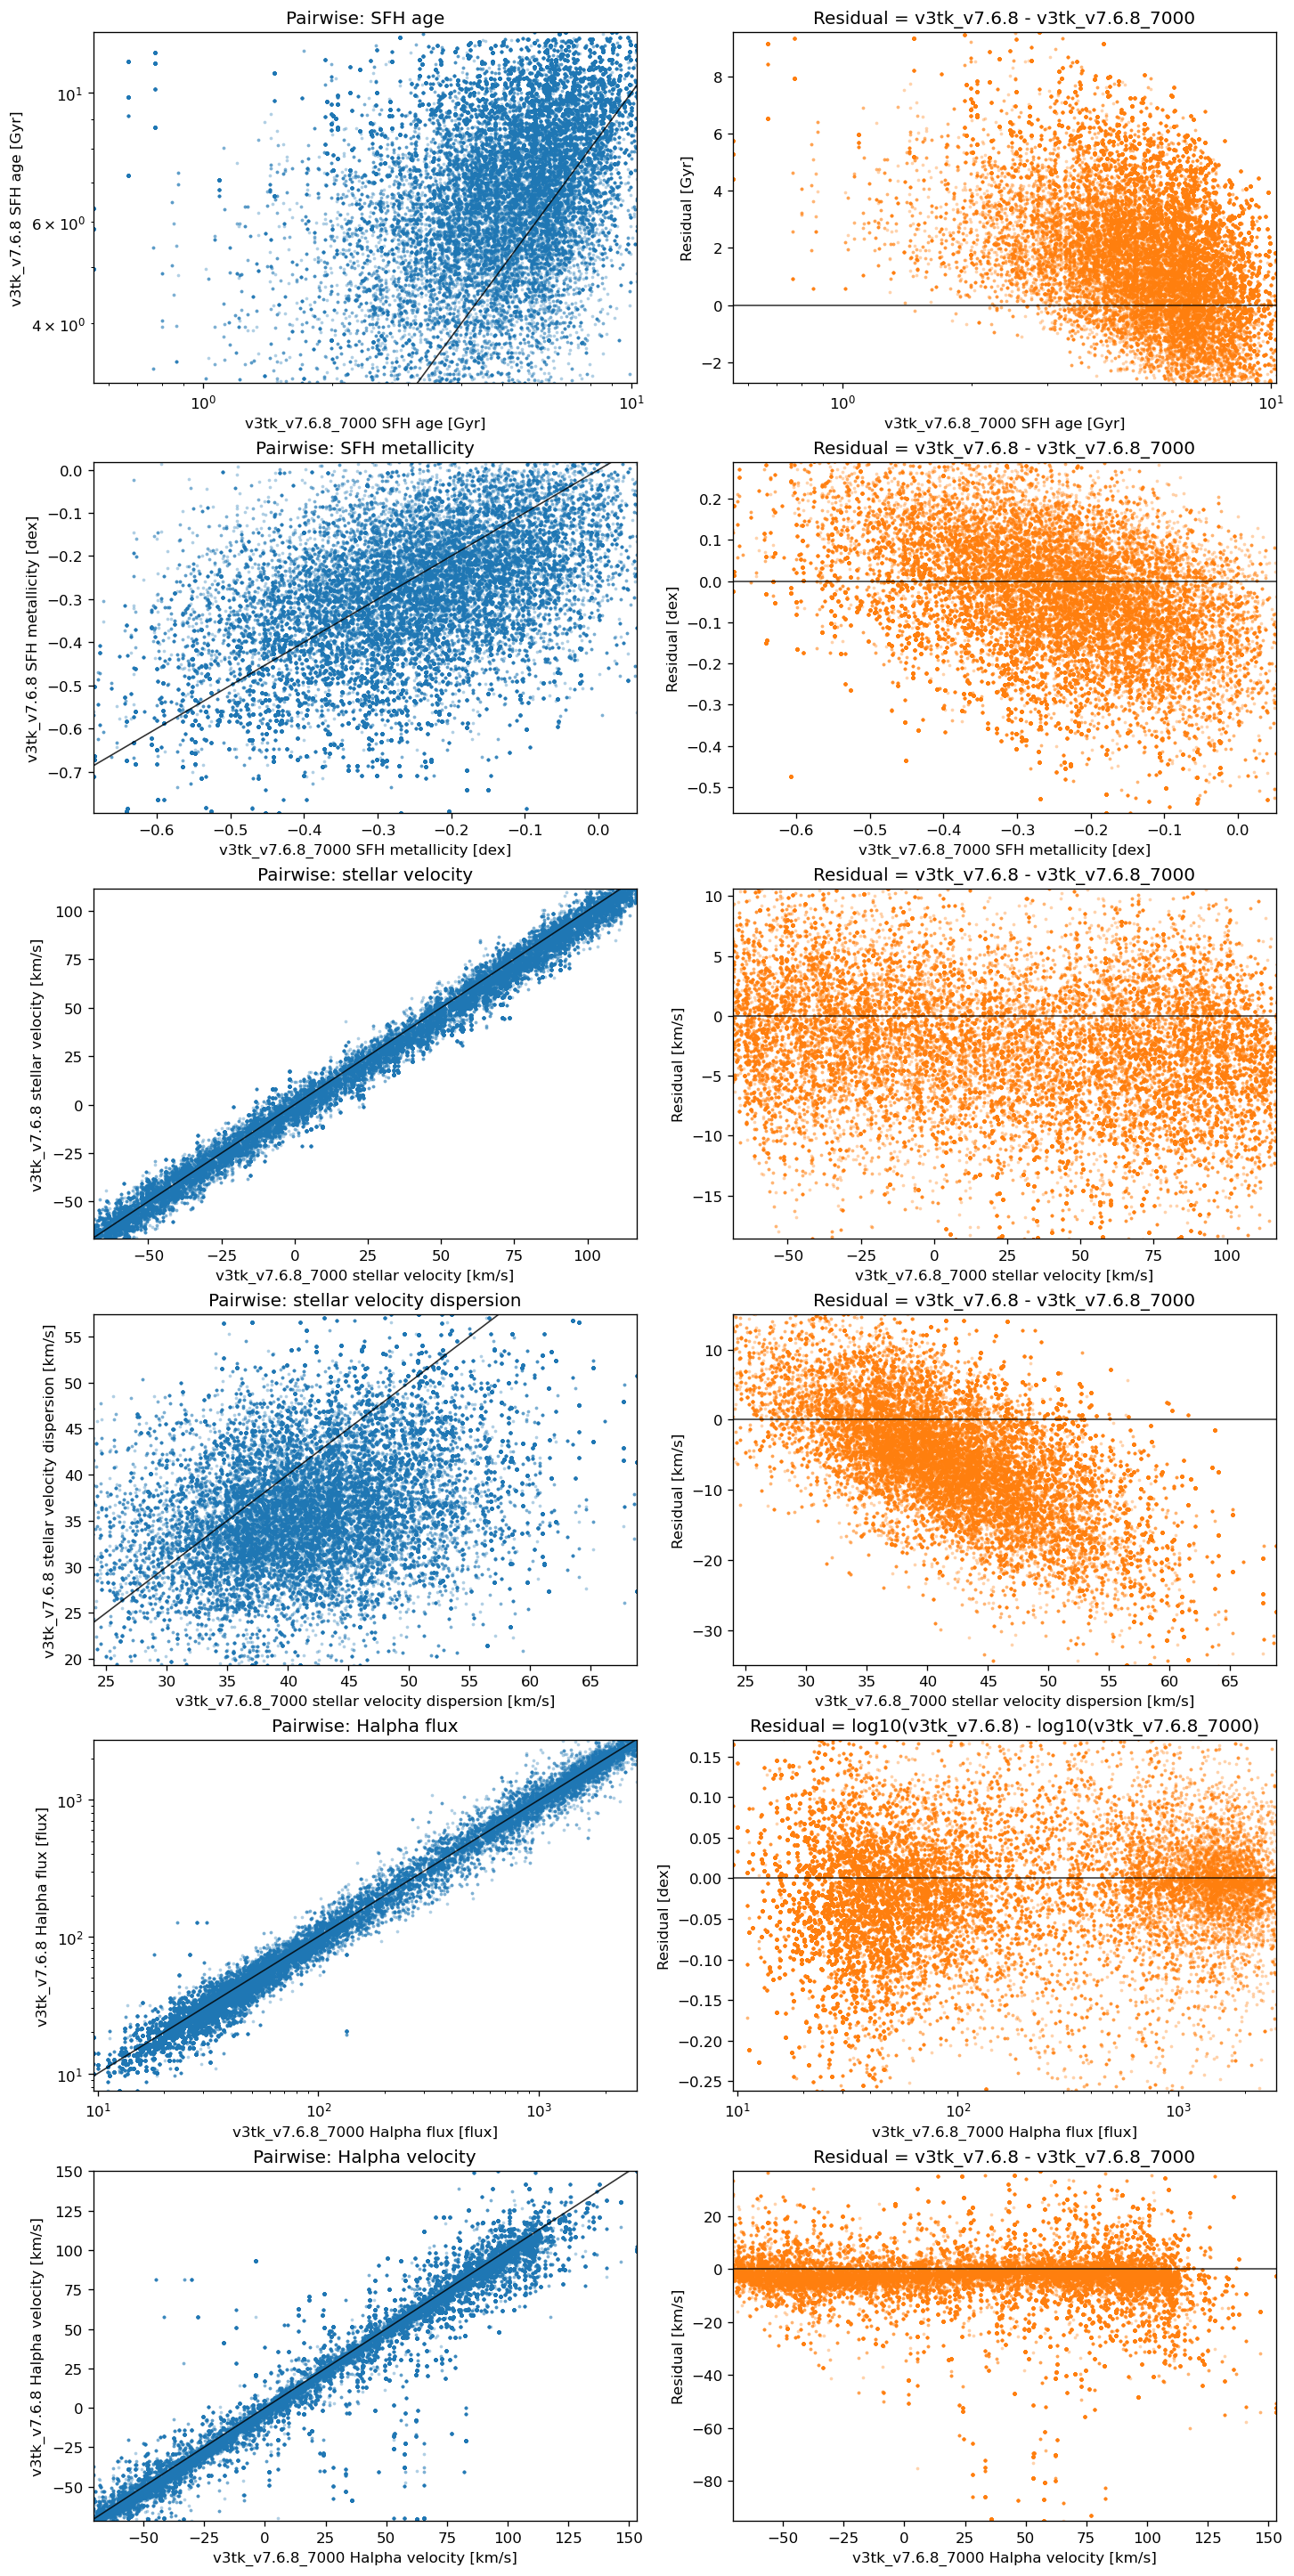

In [5]:
fig, axes = plt.subplots(len(PROPERTIES), 2, figsize=(12.0, 4.0 * len(PROPERTIES)), constrained_layout=True)
if axes.ndim == 1:
    axes = axes[None, :]

for row, (prop_key, prop) in enumerate(PROPERTIES.items()):
    table = comparison_tables[prop_key]
    x = table['ref'].to_numpy(dtype=float)
    y = table['test'].to_numpy(dtype=float)
    residual = table['residual'].to_numpy(dtype=float)

    ax = axes[row, 0]
    ax.scatter(x, y, s=5, alpha=0.35, linewidths=0, color='tab:blue')
    use_log_axes = prop.get('scatter_log_axes', False)
    use_log_residual = prop.get('scatter_log_residual', False)
    if use_log_axes:
        positive = (x > 0) & (y > 0)
        x_plot = x[positive]
        y_plot = y[positive]
        if use_log_residual:
            residual_plot = np.log10(y_plot) - np.log10(x_plot)
        else:
            residual_plot = residual[positive]
    else:
        x_plot = x
        y_plot = y
        residual_plot = residual

    xlo, xhi = finite_limits(x_plot)
    ylo, yhi = finite_limits(y_plot)
    line_lo = min(xlo, ylo)
    line_hi = max(xhi, yhi)
    ax.plot([line_lo, line_hi], [line_lo, line_hi], color='black', lw=1.0, alpha=0.8)
    ax.set_xlim(xlo, xhi)
    ax.set_ylim(ylo, yhi)
    ax.set_xlabel(f"{RUNS[REF_KEY]['label']} {prop['label']} [{prop['unit']}]")
    ax.set_ylabel(f"{RUNS[TEST_KEY]['label']} {prop['label']} [{prop['unit']}]")
    if use_log_axes:
        ax.set_xscale('log')
        ax.set_yscale('log')
    ax.set_title(f"Pairwise: {prop['label']}")

    ax = axes[row, 1]
    ax.axhline(0, color='black', lw=1.0, alpha=0.75)
    ax.scatter(x_plot, residual_plot, s=5, alpha=0.35, linewidths=0, color='tab:orange')
    xlo, xhi = finite_limits(x_plot)
    ylo, yhi = finite_limits(residual_plot)
    ax.set_xlim(xlo, xhi)
    ax.set_ylim(ylo, yhi)
    ax.set_xlabel(f"{RUNS[REF_KEY]['label']} {prop['label']} [{prop['unit']}]")
    if use_log_residual:
        ax.set_ylabel('Residual [dex]')
        ax.set_title(f"Residual = log10({RUNS[TEST_KEY]['label']}) - log10({RUNS[REF_KEY]['label']})")
    else:
        ax.set_ylabel(f"Residual [{prop['unit']}]")
        ax.set_title(f"Residual = {RUNS[TEST_KEY]['label']} - {RUNS[REF_KEY]['label']}")
    if use_log_axes:
        ax.set_xscale('log')

plt.show()


## Largest Residuals

Show the largest absolute residual pixels for each requested property.


In [6]:
largest_residual_tables = {}
for prop_key, prop in PROPERTIES.items():
    table = comparison_tables[prop_key].copy()
    table['abs_residual'] = table['residual'].abs()
    largest = table.sort_values('abs_residual', ascending=False).head(15)
    largest_residual_tables[prop_key] = largest
    print(f"\n{prop['label']} largest absolute residuals")
    display(largest[['x', 'y', 'ref', 'test', 'residual', 'abs_residual']])



SFH age largest absolute residuals


,x,y,ref,test,residual,abs_residual
26073,108,164,0.769517,11.701945,10.932428,10.932428
26736,109,166,0.769517,11.701945,10.932428,10.932428
27408,109,168,0.769517,11.701945,10.932428,10.932428
28429,107,171,0.769517,11.701945,10.932428,10.932428
28430,108,171,0.769517,11.701945,10.932428,10.932428
27410,111,168,0.769517,11.701945,10.932428,10.932428
27745,108,169,0.769517,11.701945,10.932428,10.932428
27409,110,168,0.769517,11.701945,10.932428,10.932428
27405,106,168,0.769517,11.701945,10.932428,10.932428
29122,108,173,0.769517,11.701945,10.932428,10.932428



SFH metallicity largest absolute residuals


,x,y,ref,test,residual,abs_residual
43762,96,211,-0.268187,-1.081952,-0.813765,0.813765
47428,109,220,-0.442303,-1.236869,-0.794567,0.794567
48242,111,222,-0.442303,-1.236869,-0.794567,0.794567
47836,111,221,-0.442303,-1.236869,-0.794567,0.794567
47835,110,221,-0.442303,-1.236869,-0.794567,0.794567
47834,109,221,-0.442303,-1.236869,-0.794567,0.794567
46212,112,217,-0.442303,-1.236869,-0.794567,0.794567
46213,113,217,-0.442303,-1.236869,-0.794567,0.794567
47025,113,219,-0.442303,-1.236869,-0.794567,0.794567
47024,112,219,-0.442303,-1.236869,-0.794567,0.794567



stellar velocity largest absolute residuals


...

,x,y,ref,test,residual,abs_residual
54194,373,236,73.995452,21.463932,-52.531520,52.531520
53791,375,235,73.995452,21.463932,-52.531520,52.531520
55393,368,239,73.995452,21.463932,-52.531520,52.531520
54596,372,237,73.995452,21.463932,-52.531520,52.531520
53790,374,235,73.995452,21.463932,-52.531520,52.531520
54995,370,238,73.995452,21.463932,-52.531520,52.531520
29969,256,175,60.414075,15.286573,-45.127502,45.127502
91032,170,377,0.536842,43.870841,43.333999,43.333999
91036,174,377,0.536842,43.870841,43.333999,43.333999
90801,175,375,0.536842,43.870841,43.333999,43.333999



Halpha flux largest absolute residuals


,x,y,ref,test,residual,abs_residual
33983,262,186,5926.495504,4286.613644,-1639.881860,1639.881860
31765,263,180,4658.659911,3073.632855,-1585.027057,1585.027057
55219,194,239,2943.131691,4498.554796,1555.423105,1555.423105
54016,195,236,2781.658753,4305.963585,1524.304832,1524.304832
67500,231,272,3188.608137,1671.276579,-1517.331558,1517.331558
32140,274,181,4927.813344,3436.310854,-1491.502491,1491.502491
32131,265,181,4278.403154,5762.324723,1483.921569,1483.921569
35129,264,189,4598.850751,3134.180804,-1464.669947,1464.669947
68496,228,275,2337.361029,3788.219142,1450.858112,1450.858112
55617,193,240,3825.144503,2374.613294,-1450.531209,1450.531209



Halpha velocity largest absolute residuals


,x,y,ref,test,residual,abs_residual
71211,75,284,132.650881,-272.275968,-404.926849,404.926849
72430,73,288,-266.738635,129.702098,396.440734,396.440734
71826,75,286,-266.738635,129.702098,396.440734,396.440734
72129,74,287,-266.738635,129.702098,396.440734,396.440734
72130,75,287,-266.738635,129.702098,396.440734,396.440734
72431,74,288,-266.738635,129.702098,396.440734,396.440734
72728,72,289,-266.738635,129.702098,396.440734,396.440734
73024,71,290,-266.738635,129.702098,396.440734,396.440734
73317,70,291,-266.738635,129.702098,396.440734,396.440734
74183,68,294,-266.738635,129.702098,396.440734,396.440734


## Notes For Reading This Notebook

- The `_7000` product is the fiducial/reference product throughout.
- Residual maps and scatter residuals use `v3tk_v7.6.8 - v3tk_v7.6.8_7000`.
- The notebook compares `AGE`, `METAL`, `V`, `SIGMA`, `HA6562_FLUX`, and `HA6562_VEL` only.
